In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=UserWarning, append=True)

### Here, we are importing the dataset that has already been cleaned and processed for null values.

In [2]:
X_train_clean= pd.read_csv('Clean_kidney_data.csv')
print(f"Shape: {X_train_clean.shape}  →  {X_train_clean.shape[0]} records, {X_train_clean.shape[1]} features")
pd.set_option('display.max_columns', None)
X_train_clean.head()

Shape: (317, 25)  →  317 records, 25 features


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,rbc_is_missing
0,45.0,80.0,1.015,0.0,0.0,normal,abnormal,notpresent,notpresent,107.0,15.0,1.0,141.0,4.2,11.800000,37.000000,10200.0,4.200000,no,no,no,good,no,no,1
1,59.0,100.0,1.015,4.0,2.0,normal,normal,notpresent,notpresent,255.0,132.0,12.8,135.0,5.7,7.300000,20.000000,9800.0,3.900000,yes,yes,yes,good,no,yes,0
2,45.0,60.0,1.010,2.0,0.0,normal,abnormal,present,notpresent,268.0,86.0,4.0,134.0,5.1,10.000000,29.000000,9200.0,4.721495,yes,yes,no,good,no,no,0
3,48.0,110.0,1.015,3.0,0.0,abnormal,normal,present,notpresent,106.0,215.0,15.2,120.0,5.7,8.600000,26.000000,5000.0,2.500000,yes,no,yes,good,no,yes,0
4,60.0,50.0,1.010,0.0,0.0,normal,normal,notpresent,notpresent,261.0,58.0,2.2,113.0,3.0,12.525091,25.237737,4200.0,3.400000,yes,no,no,good,no,no,1


In [3]:
X_test_clean= pd.read_csv('X_test_clean.csv')
print(f"Shape: {X_test_clean.shape}  →  {X_test_clean.shape[0]} records, {X_test_clean.shape[1]} features")

Shape: (80, 25)  →  80 records, 25 features


In [4]:
y_train= pd.read_csv('y_train.csv')
y_train.shape

(317, 1)

In [5]:
y_test=pd.read_csv('y_test.csv')
y_test.shape

(80, 1)

## Convert the Categorical features into Numarical features

In [6]:
from sklearn.preprocessing import OneHotEncoder

X_train_encoded = X_train_clean.copy()
X_test_encoded  = X_test_clean.copy()

# here we find the categorical features as bianry and multiple class in X_train_encoded
#====================================================================================
text_columns = [
    col for col in X_train_encoded.select_dtypes(include=['object', 'category']).columns 
    if not col.endswith('_is_missing')
]

binary_cols = [col for col in text_columns if X_train_encoded[col].nunique() <= 2]
multiclass_cols = [col for col in text_columns if X_train_encoded[col].nunique() > 2]

print("=== Encoding Feature Categorization ===")
print(f"🔹 Binary features mapped ({len(binary_cols)})")
print(f"🔹 Multi-class features mapped ({len(multiclass_cols)})\n")
# ====================================================================================


# encoding our binary categorical features
# ====================================================================================
if binary_cols:
    for col in binary_cols:
        # Cast to standard string arrays and read the unique elements present in the training set
        train_categories = X_train_encoded[col].astype(str).unique()
        
        # Build an explicit, clean 0/1 integer index mapping dictionary layout
        binary_map = {category_name: index for index, category_name in enumerate(train_categories[:2])}
        
        # Apply mapping across columns simultaneously via native vectorized math.
        # Unknown values in test split are safely caught using .fillna(0) to prevent rogue negative coordinates
        X_train_encoded[col] = X_train_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
        X_test_encoded[col]  = X_test_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
# ====================================================================================


# Here we are encoding the multi class categorical columns
# ====================================================================================
if multiclass_cols:
    # Initialize encoder. handle_unknown='ignore' ensures any brand-new unseen test categories are silently dropped
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    
    # Fit on training data and transform arrays via C-speed matrix operations
    train_ohe_array = ohe.fit_transform(X_train_encoded[multiclass_cols].astype(str))
    test_ohe_array  = ohe.transform(X_test_encoded[multiclass_cols].astype(str))
    
    # Generate human-readable new feature names (e.g., 'feature_category')
    new_column_names = ohe.get_feature_names_out(multiclass_cols)
    
    # Package matrices back into beautifully structured dataframes, keeping original index numbers aligned
    train_ohe_df = pd.DataFrame(train_ohe_array, columns=new_column_names, index=X_train_encoded.index)
    test_ohe_df  = pd.DataFrame(test_ohe_array,  columns=new_column_names, index=X_test_encoded.index)
    
    # Clean drop old original text string variables and append the newly created binary dummy columns
    X_train_encoded = pd.concat([X_train_encoded.drop(columns=multiclass_cols), train_ohe_df], axis=1)
    X_test_encoded  = pd.concat([X_test_encoded.drop(columns=multiclass_cols),  test_ohe_df],  axis=1)
# ====================================================================================

=== Encoding Feature Categorization ===
🔹 Binary features mapped (10)
🔹 Multi-class features mapped (0)



In [7]:
X_train_encoded.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,rbc_is_missing
0,45.0,80.0,1.015,0.0,0.0,0,0,0,0,107.0,15.0,1.0,141.0,4.2,11.800000,37.000000,10200.0,4.200000,0,0,0,0,0,0,1
1,59.0,100.0,1.015,4.0,2.0,0,1,0,0,255.0,132.0,12.8,135.0,5.7,7.300000,20.000000,9800.0,3.900000,1,1,1,0,0,1,0
2,45.0,60.0,1.010,2.0,0.0,0,0,1,0,268.0,86.0,4.0,134.0,5.1,10.000000,29.000000,9200.0,4.721495,1,1,0,0,0,0,0
3,48.0,110.0,1.015,3.0,0.0,1,1,1,0,106.0,215.0,15.2,120.0,5.7,8.600000,26.000000,5000.0,2.500000,1,0,1,0,0,1,0
4,60.0,50.0,1.010,0.0,0.0,0,1,0,0,261.0,58.0,2.2,113.0,3.0,12.525091,25.237737,4200.0,3.400000,1,0,0,0,0,0,1


## Scaling the features using StandardScaler

In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler instance
scaler = StandardScaler()

# 2. FIT & TRANSFORM: Training split conversion
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded), 
    columns=X_train_encoded.columns, 
    index=X_train_encoded.index
)

# 3. TRANSFORM ONLY: Test split conversion (Prevents Data Leakage)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded), 
    columns=X_test_encoded.columns, 
    index=X_test_encoded.index
)

In [9]:
X_train_scaled.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,rbc_is_missing
0,-0.355574,0.221825,-0.456510,-0.683033,-0.349513,-0.357930,-2.007921,-0.37455,-0.2595,-0.490939,-0.860391,-0.500235,0.555572,-0.237654,-2.615514e-01,-0.178261,0.649134,-0.623586,-0.754524,-0.683807,-0.286201,-0.488141,-0.473221,-0.427593,1.255880
1,0.471057,1.656898,-0.456510,2.399125,1.702256,-0.357930,0.498028,-0.37455,-0.2595,1.570446,1.582149,3.160128,-0.432647,2.012331,-1.884770e+00,-2.227500,0.499169,-0.982315,1.325338,1.462400,3.494043,-0.488141,-0.473221,2.338672,-0.796254
2,-0.355574,-1.213247,-1.403598,0.858046,-0.349513,-0.357930,-2.007921,2.66987,-0.2595,1.751513,0.621834,0.430366,-0.597350,1.112337,-9.108388e-01,-1.142609,0.274220,0.000000,1.325338,1.462400,-0.286201,-0.488141,-0.473221,-0.427593,-0.796254
3,-0.178439,2.374434,-0.456510,1.628585,-0.349513,2.793842,0.498028,2.66987,-0.2595,-0.504867,3.314890,3.904609,-2.903195,2.012331,-1.415840e+00,-1.504239,-1.300419,-2.656385,1.325338,-0.683807,3.494043,-0.488141,-0.473221,2.338672,-0.796254
4,0.530102,-1.930784,-1.403598,-0.683033,-0.349513,-0.357930,0.498028,-0.37455,-0.2595,1.654015,0.037294,-0.127994,-4.056117,-2.037643,6.407590e-16,-1.596125,-1.600350,-1.580197,1.325338,-0.683807,-0.286201,-0.488141,-0.473221,-0.427593,1.255880


### Here we established a baseline performance benchmark for our classification model

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_dummy_pred = dummy.predict(X_test_scaled)

print("=== Baseline (DummyClassifier — Majority Class) ===")
print(f"Accuracy : {accuracy_score(y_test, y_dummy_pred)*100:.2f}%")
print(f"F1-Score : {f1_score(y_test, y_dummy_pred, zero_division=0)*100:.2f}%")
print("\nAny real model MUST score better than this baseline.")

=== Baseline (DummyClassifier — Majority Class) ===
Accuracy : 62.50%
F1-Score : 76.92%

Any real model MUST score better than this baseline.


## To detect the multicollinearity

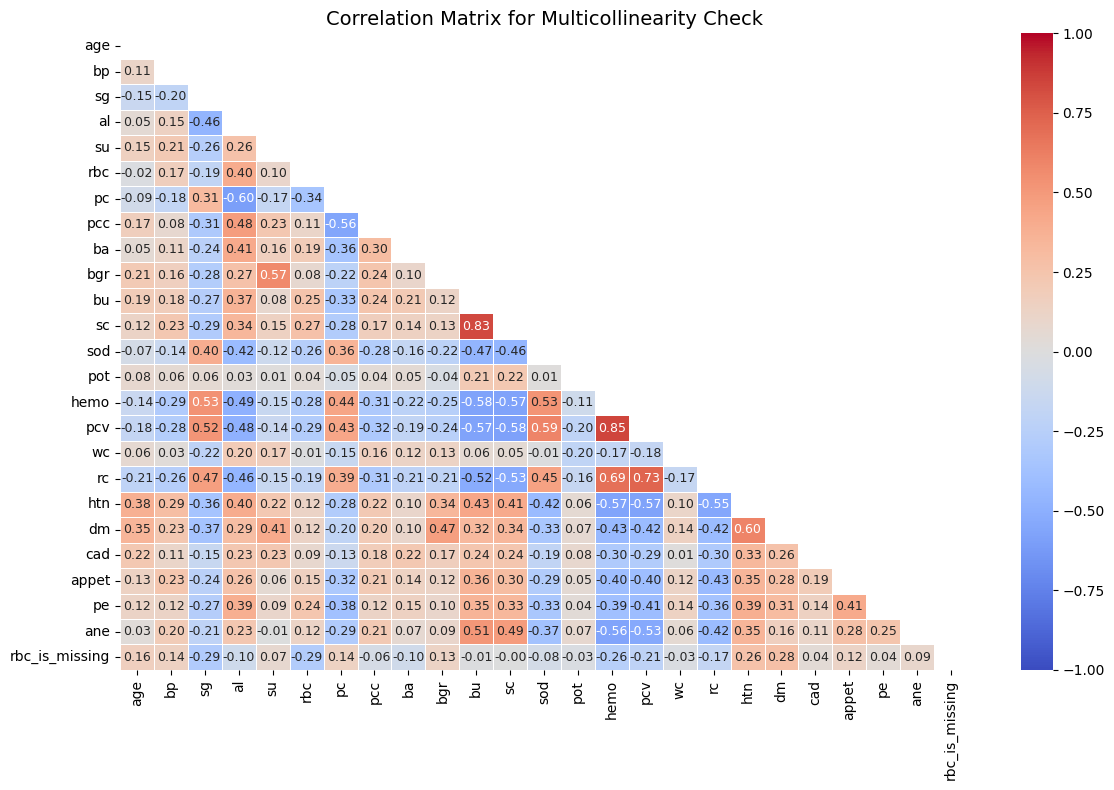


--- Variance Inflation Factor (VIF) Scores ---
           Feature       VIF
0              pcv  5.134712
1             hemo  4.685318
2               bu  3.910491
3               sc  3.842667
4               rc  2.565562
5               al  2.435878
6              htn  2.424666
7               pc  2.213192
8               dm  2.089528
9               sg  1.883530
10             sod  1.857543
11             ane  1.781166
12              su  1.778527
13             pcc  1.775285
14             bgr  1.774878
15  rbc_is_missing  1.654005
16              pe  1.549886
17             rbc  1.513789
18           appet  1.451701
19             age  1.344978
20              ba  1.339658
21             cad  1.292663
22             pot  1.270840
23              wc  1.250790
24              bp  1.238593


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 2. METHOD A: VISUAL CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
corr_matrix = X_train_scaled.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix for Multicollinearity Check', fontsize=14)
plt.tight_layout()
plt.show()


# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns

# Calculate VIF score for each feature
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]

# Sort features by VIF score in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Variance Inflation Factor (VIF) Scores ---")
print(vif_data)

### From the results, 'pcv' and 'hemo' are highly correlated features. Therefore, to avoid multicollinearity, we have to drop one of these two.

# Find the Feature Importance

--- Top 10 Most Important Features ---
          Feature  Importance
0             pcv    0.224801
1              sg    0.183671
2            hemo    0.179001
3              sc    0.084855
4              al    0.080782
5             htn    0.058385
6              rc    0.057787
7              dm    0.023225
8  rbc_is_missing    0.022593
9              bu    0.019364


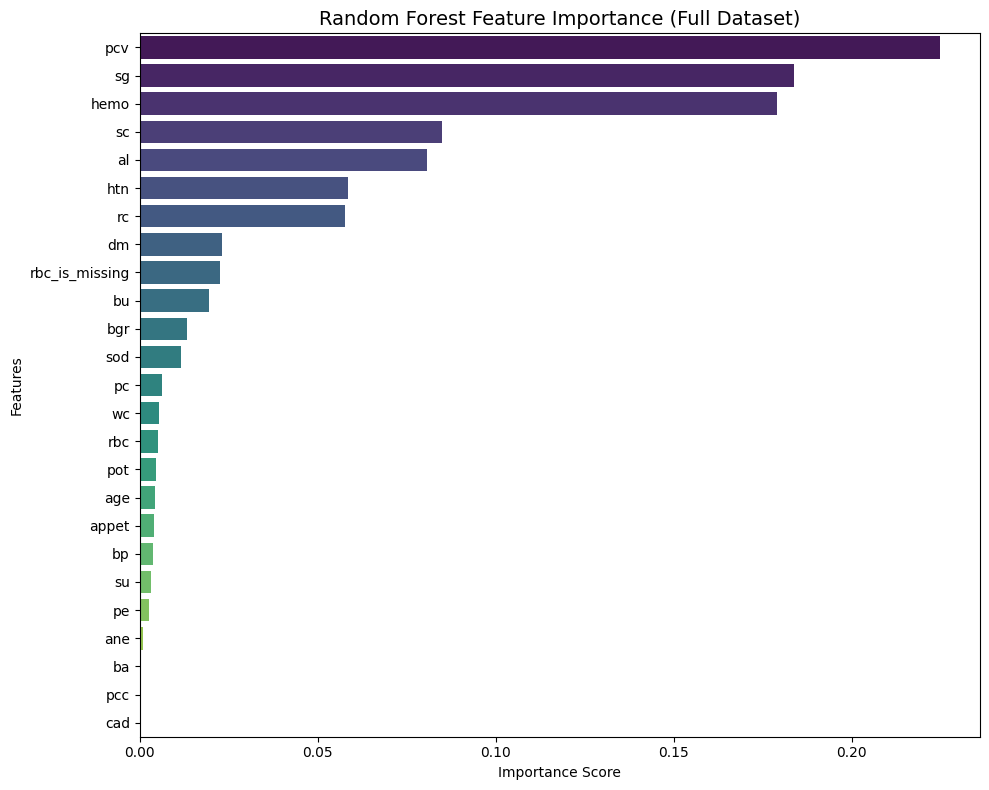

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. INITIALIZE AND TRAIN THE MODEL (Using your full 25-feature matrix)
# Random Forest handles scaled variables and categorical encoders perfectly out of the box
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. EXTRACT SCORES AND PAIR THEM WITH COLUMN NAMES
importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 10 Most Important Features ---")
print(importance_df.head(10))

# 3. PLOT THE FEATURE IMPORTANCE
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Random Forest Feature Importance (Full Dataset)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### To select the features that need to be dropped.

### 1. Null values : 'pcv' = 17.98% ___________'hemo' = 13.25% 
### 2. VIF Score :     'pcv' = 5.134712 ___________'hemo' = 4.685318
### 3. Feature Importance  (Predictive Power) :    'pcv' = 0.224801 __________'hemo' = 0.179001

### Based on all of these metrics, we chose to drop the feature 'hemo'

In [13]:
# 1. Drop 'hemo' from the training data to eliminate multicollinearity
X_train_final = X_train_scaled.drop(columns=['hemo'])

# 2. Mirror the exact same step on the testing data
X_test_final = X_test_scaled.drop(columns=['hemo'])

# --- Quick verification check ---
print(f"Cleaned Data Shapes -> Train: {X_train_final.shape} | Test: {X_test_final.shape}")
# Both should now show 24 columns instead of 25!

Cleaned Data Shapes -> Train: (317, 24) | Test: (80, 24)


### Here, we are selecting features for the best performance using RFECV

--- RFE Selection Summary ---
Original number of features : 24
Number of selected features  : 9

✅ SELECTED FEATURES:
['sg', 'al', 'bgr', 'bu', 'sc', 'pcv', 'rc', 'htn', 'rbc_is_missing']



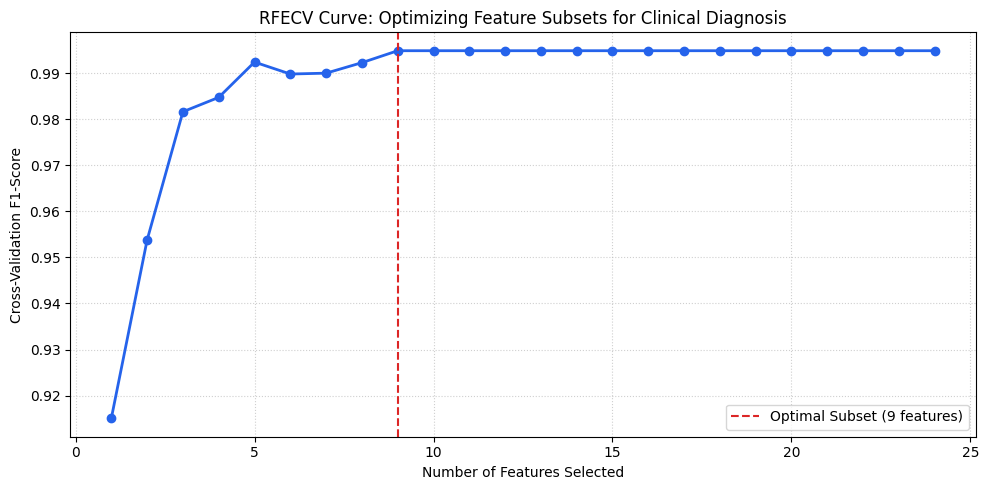

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# 1. Initialize core estimator and CV strategy
estimator   = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Fit RFECV using F1-Scoring (Vital for medical data optimization)
rfecv = RFECV(estimator=estimator, step=1, cv=cv_strategy, scoring='f1', n_jobs=-1)
rfecv.fit(X_train_final, y_train)

# 3. Extract optimal indices
optimal_n      = rfecv.n_features_
selected_feats = X_train_final.columns[rfecv.support_].tolist()

# Fixed: Explicitly printing the exact column selections for your visual audit
print("--- RFE Selection Summary ---")
print(f"Original number of features : {X_train_final.shape[1]}")
print(f"Number of selected features  : {optimal_n}")

print("\n✅ SELECTED FEATURES:")
print(selected_feats)
print()

# 4. Plot the RFECV F1 Performance Curve
plt.figure(figsize=(10, 5))
scores = rfecv.cv_results_['mean_test_score'] if hasattr(rfecv, 'cv_results_') else rfecv.grid_scores_

plt.plot(range(1, len(scores) + 1), scores, marker='o', color='#2563EB', linewidth=2)
plt.axvline(x=optimal_n, color='#DC2626', linestyle='--', label=f'Optimal Subset ({optimal_n} features)')
plt.xlabel('Number of Features Selected')
plt.ylabel('Cross-Validation F1-Score')
plt.title('RFECV Curve: Optimizing Feature Subsets for Clinical Diagnosis')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Creating a new DataFrame with only the RFECV-selected features for model creation

In [15]:
# The elite, dynamic pandas execution way
X_train_selected = X_train_final[selected_feats]
X_test_selected  = X_test_final[selected_feats]

print(f"\nFinal Ready Shapes ➔ Train: {X_train_selected.shape} | Test: {X_test_selected.shape}\n")


Final Ready Shapes ➔ Train: (317, 9) | Test: (80, 9)



In [16]:
print("--- Features Matrix Columns Verification ---")
print(list(X_train_selected.columns))
print()

--- Features Matrix Columns Verification ---
['sg', 'al', 'bgr', 'bu', 'sc', 'pcv', 'rc', 'htn', 'rbc_is_missing']



## Multi-Model Performance Benchmarking 
We test 7 different models at the same time. To save time and keep the test fair, we use cross-validation on the training data using all CPU cores. Then, we train each model on the full training set and test it on hidden data. The final table is sorted by the cross-validation score.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Keep your exact models intact
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Robust cross-validation setup
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELS = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "KNN":                 KNeighborsClassifier(),
    "SVM (RBF)":           SVC(kernel="rbf", random_state=42, class_weight='balanced'),
    "Naive Bayes":         GaussianNB(),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest":       RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

results = []
for name, model in MODELS.items():
    
    # 1. Step A: Compute the Cross-Validation Score on Training Data
    cv_scores = cross_val_score(model, X_train_selected, y_train, cv=cv5, scoring='f1', n_jobs=-1)
    mean_cv_f1 = cv_scores.mean()
    
    # 2. Step B: Train ONCE on full training data to predict on the test set
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    # 3. Collect all metrics for this model row
    results.append({
        "Model": name,
        "CV F1 (Train)":  mean_cv_f1, # Store as float first for clean sorting
        "Test Accuracy":  accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Test Recall":    recall_score(y_test, y_pred, pos_label=1),
        "Test F1":        f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    })

# 4. Turn into a DataFrame
df_results = pd.DataFrame(results)

# 5. Rank the table by CV F1 score as planned
df_results = df_results.sort_values(by="CV F1 (Train)", ascending=False).reset_index(drop=True)

# 6. Beautifully format everything to percentages for display
metric_cols = ["CV F1 (Train)", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
for col in metric_cols:
    df_results[col] = df_results[col].map(lambda x: f"{x*100:.2f}%")

print("\n🏆 OPTIMIZED MODEL BENCHMARK TABLE (Ranked by CV F1)")
print("="*85)
display(df_results)


🏆 OPTIMIZED MODEL BENCHMARK TABLE (Ranked by CV F1)


,Model,CV F1 (Train),Test Accuracy,Test Precision,Test Recall,Test F1
0,Random Forest,99.49%,100.00%,100.00%,100.00%,100.00%
1,SVM (RBF),99.23%,100.00%,100.00%,100.00%,100.00%
2,Logistic Regression,98.71%,98.75%,100.00%,98.00%,98.99%
3,Decision Tree,98.46%,96.25%,97.96%,96.00%,96.97%
4,KNN,98.21%,100.00%,100.00%,100.00%,100.00%
5,Gradient Boosting,98.20%,98.75%,100.00%,98.00%,98.99%
6,Naive Bayes,94.32%,93.75%,100.00%,90.00%,94.74%


## Hyperparameter Tuning: Optimizing the Random Forest Model
We use GridSearchCV to fine-tune our top-performing Random Forest model by testing different tree counts, depths, and split constraints. Following clinical priorities, the search optimizes explicitly for Recall to minimize dangerous false negatives and ensure true positive cases are not missed.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold


param_grid = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [None, 5, 10],           
    'min_samples_split': [2, 5],         
    'min_samples_leaf': [1, 2]             
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Set up Grid Search for Random Forest algorithm
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='recall',   # Recall is the ideal metric for medical scenarios because it minimizes false negatives.
    n_jobs=-1
)

grid_search.fit(X_train_selected, y_train)
best_rf_model = grid_search.best_estimator_

print()
print("\n🏆 GRID SEARCH COMPLETE")
print(f"Best RF Parameters : {grid_search.best_params_}")
print(f"Best CV Recall     : {grid_search.best_score_*100:.2f}%")
print()



🏆 GRID SEARCH COMPLETE
Best RF Parameters : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Recall     : 99.49%



## Final Model Evaluation & Diagnostic Plots
We test our optimized model on Test dataset to check its real-world accuracy. The classification report and confusion matrix show the exact breakdown of patient predictions. The ROC Curve measures the model's confidence, proving how safely it separates Chronic Kidney Disease (CKD) from healthy cases.

FINAL TUNED MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Healthy (0)       1.00      1.00      1.00        30
     CKD (1)       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



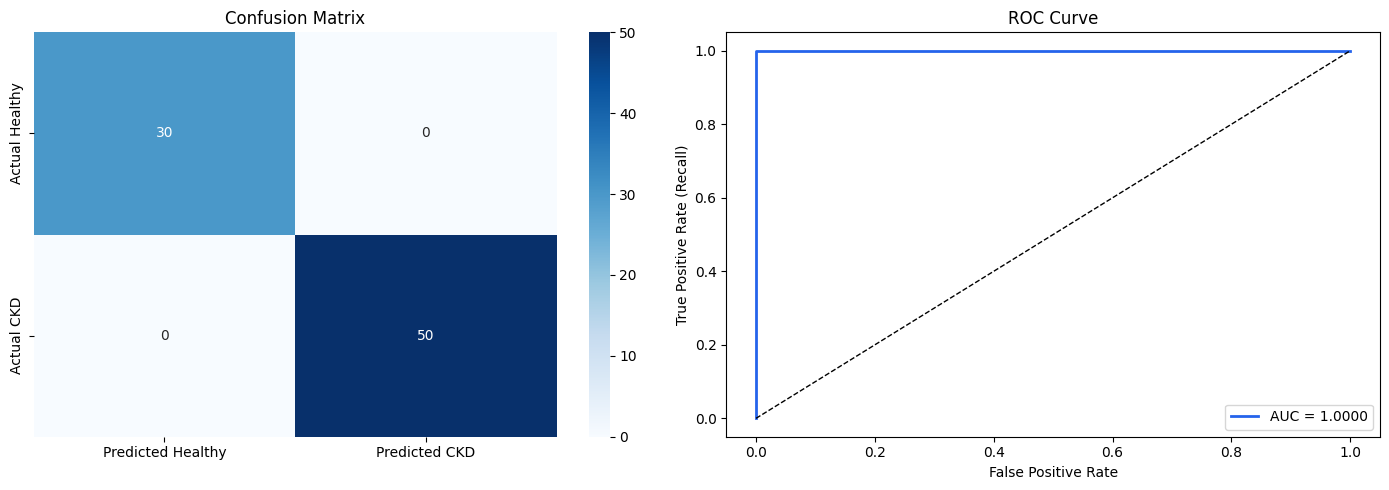


ROC-AUC Score: 100.00%



In [19]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

y_pred = best_rf_model.predict(X_test_selected)
y_prob = best_rf_model.predict_proba(X_test_selected)[:, 1]

print("FINAL TUNED MODEL — CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'CKD (1)']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted CKD'],
            yticklabels=['Actual Healthy', 'Actual CKD'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2563EB', linewidth=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nROC-AUC Score: {auc_score*100:.2f}%\n") 

## Clinical Feature Importance Ranking
This block extracts the importance scores directly from our optimized Random Forest model. It ranks our features from highest to lowest to show exactly which clinical measurements (like `pcv`, `sg`, and `sc`) have the biggest impact on the model's diagnostic decisions.

In [20]:
importances = best_rf_model.feature_importances_

clinical_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance Score': importances,
    'Contribution': ['High Impact' if imp > 0.10 else 'Moderate/Low Impact' for imp in importances]
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

print("🏆 CLINICAL FEATURE IMPORTANCE RANKING")
print("="*55)
display(clinical_df)

🏆 CLINICAL FEATURE IMPORTANCE RANKING


,Feature,Importance Score,Contribution
0,pcv,0.295989,High Impact
1,sg,0.227007,High Impact
2,sc,0.158153,High Impact
3,al,0.126245,High Impact
4,rc,0.085903,Moderate/Low Impact
5,htn,0.039894,Moderate/Low Impact
6,rbc_is_missing,0.035979,Moderate/Low Impact
7,bgr,0.018757,Moderate/Low Impact
8,bu,0.012072,Moderate/Low Impact


## Saving Production Model & Pipeline Assets for Deployment
This final block saves our trained Random Forest model, the feature scaler, and our selected feature list as files (`.joblib`). Saving these tools makes deployment easy, allowing us to load the complete pipeline later and make instant predictions on new patients without re-training the model.

In [21]:
import os
import joblib

joblib.dump(best_rf_model, 'final_ckd_model.joblib')

joblib.dump(scaler, 'scaler.joblib')          

# Save your active selected feature strings list directly for dynamic inference mapping
joblib.dump(selected_feats, 'selected_features.joblib') 

# 2. Execute Local Physical File Integrity Logs
asset_files = ['final_ckd_model.joblib', 'scaler.joblib', 'selected_features.joblib']
print()

for file_name in asset_files:
    if os.path.exists(file_name):
        size_kb = os.path.getsize(file_name) / 1024
        print(f"  • File Name: '{file_name:<25}' | File Size: {size_kb:.2f} KB")
    else:
        print(f"  🚨 ERROR: Failed to serialize file: '{file_name}'")
print()


  • File Name: 'final_ckd_model.joblib   ' | File Size: 99.21 KB
  • File Name: 'scaler.joblib            ' | File Size: 1.56 KB
  • File Name: 'selected_features.joblib ' | File Size: 0.07 KB



## Pre-Deployment Safety Audit & Stress Test
Before deploying our model, we run a final health check on our saved files (`.joblib`). This block confirms the files exist, load correctly, make predictions instantly, and can handle extreme high-risk patient data safely.

In [22]:
import time
import warnings

# Suppress scikit-learn's 1D array warning noise globally
warnings.filterwarnings('ignore', category=UserWarning, append=True)

def run_pre_deployment_checks(model_path, scaler_path, sample_X, sample_y):
    print("=" * 55)
    print("🛡️ PRODUCTION-GRADE MODEL INTEGRITY AUDIT")
    print("=" * 55)

    print("\n1. File existence check...")
    if os.path.exists(model_path) and os.path.exists(scaler_path):
        print(f"  [PASS] Deployment assets found.")
    else:
        print("  [FAIL] Missing asset files!"); return

    print("\n2. Loading check...")
    try:
        deployed_scaler = joblib.load(scaler_path)
        deployed_model = joblib.load(model_path)
        print("  [PASS] Model and Scaler successfully loaded into memory.")
    except Exception as e:
        print(f"  [FAIL] Deserialization failed: {e}"); return

    print("\n3. Prediction latency check...")
    batch = sample_X.head(5)
    # Flatten the 2D true array to a 1D array to match the model's prediction shape
    true  = sample_y.head(5).values.ravel()
    t0    = time.time()
    preds = deployed_model.predict(batch)
    ms    = (time.time() - t0) * 1000
    print(f"  [PASS] Prediction Latency: {ms:.2f} ms")
    
    mismatches = np.sum(preds != true)
    if mismatches == 0:
        print("  [PASS] Saved model output matches training baseline.")
    else:
        print(f"  [WARN] Prediction mismatch detected on 5-sample batch."); return

    print("\n4. End-to-End Edge-Case Pipeline Stress Test...")
    try:
        all_original_features = list(deployed_scaler.feature_names_in_)
        extreme_patient = pd.DataFrame([{col: 0.0 for col in all_original_features}])
        
        # Injecting severe clinical markers using only valid features
        extreme_patient['sg']   = 1.005
        extreme_patient['al']   = 4.0
        extreme_patient['bgr']  = 350.0
        extreme_patient['sc']   = 12.0
        extreme_patient['rc']   = 2.1
        extreme_patient['htn']  = 1
        
        # Safely handle 'hemo' only if your scaler object still expects it
        if 'hemo' in extreme_patient.columns:
            extreme_patient['hemo'] = 0.0
        if 'rbc_is_missing' in extreme_patient.columns:
            extreme_patient['rbc_is_missing'] = 0

        # Align columns to match the exact order the scaler expects
        extreme_patient = extreme_patient[all_original_features]
        
        # Transform using the deployment scaler instance
        scaled_extreme = pd.DataFrame(
            deployed_scaler.transform(extreme_patient), 
            columns=all_original_features, 
            index=extreme_patient.index
        )
        
        # Slice columns down to match the exact feature names used by the final Random Forest
        extreme_features = scaled_extreme[list(sample_X.columns)]
        
        # Generate the final risk probability
        prob = deployed_model.predict_proba(extreme_features)[:, 1][0]
        print(f"  • Raw Patient Data successfully Scaled ➔ Model Scored.")
        print(f"  • Extreme patient CKD probability: {prob*100:.2f}%")
        print("  [PASS]" if prob > 0.90 else "  [WARN] Unexpectedly low risk score for critical case.")
            
    except Exception as e:
        print(f"  [FAIL] Deployment pipeline crashed! Error: {e}")
        return

    print("\n" + "=" * 55)
    print("🎉 DEPLOYMENT AUDIT COMPLETE: PIPELINE IS SECURE")
    print("=" * 55)

# Run the complete, secure end-to-end framework
run_pre_deployment_checks('final_ckd_model.joblib', 'scaler.joblib', X_test_selected, y_test)


🛡️ PRODUCTION-GRADE MODEL INTEGRITY AUDIT

1. File existence check...
  [PASS] Deployment assets found.

2. Loading check...
  [PASS] Model and Scaler successfully loaded into memory.

3. Prediction latency check...
  [PASS] Prediction Latency: 0.00 ms
  [PASS] Saved model output matches training baseline.

4. End-to-End Edge-Case Pipeline Stress Test...
  • Raw Patient Data successfully Scaled ➔ Model Scored.
  • Extreme patient CKD probability: 92.00%
  [PASS]

🎉 DEPLOYMENT AUDIT COMPLETE: PIPELINE IS SECURE
